In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df.columns

Index(['Category', 'Message'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [7]:
df['Category'].unique()

array(['ham', 'spam'], dtype=object)

In [8]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [9]:
df['Category'].value_counts(normalize=True) * 100

Category
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

In [10]:
df.duplicated().sum()

np.int64(415)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(5157, 2)

In [13]:
df.columns = df.columns.str.strip().str.lower()

In [14]:
df.columns

Index(['category', 'message'], dtype='object')

In [15]:
df.isnull().sum()

category    0
message     0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

### Create Text-Based Features

In [17]:
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

In [18]:
df['character_count'] = df['message'].apply(len)

In [19]:
df.head()

,category,message,word_count,character_count
0,ham,"Go until jurong point, crazy.. Available only ...",20,111
1,ham,Ok lar... Joking wif u oni...,6,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,155
3,ham,U dun say so early hor... U c already then say...,11,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,61


### Statistical Summary

In [21]:
df[['character_count', 'word_count']].describe()

,character_count,word_count
count,5157.000000,5157.000000
mean,79.228040,15.410704
std,58.451149,11.118902
min,2.000000,1.000000
25%,36.000000,7.000000
50%,61.000000,12.000000
75%,118.000000,22.000000
max,910.000000,171.000000


#### Spam vs Ham Message Length

In [22]:
df.groupby('category')[['character_count', 'word_count']].mean()

,character_count,word_count
category,,
ham,70.951063,14.239814
spam,137.541342,23.659906


### Visualization

#### Spam vs Ham Distribution

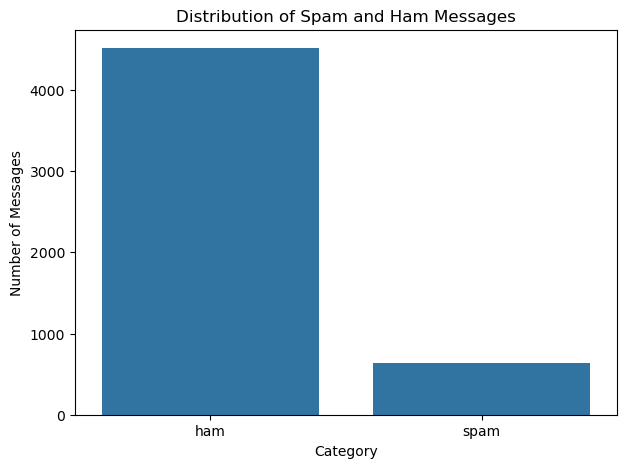

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='category')

plt.title('Distribution of Spam and Ham Messages')
plt.xlabel('Category')
plt.ylabel('Number of Messages')

plt.show()

#### Percentage Distribution

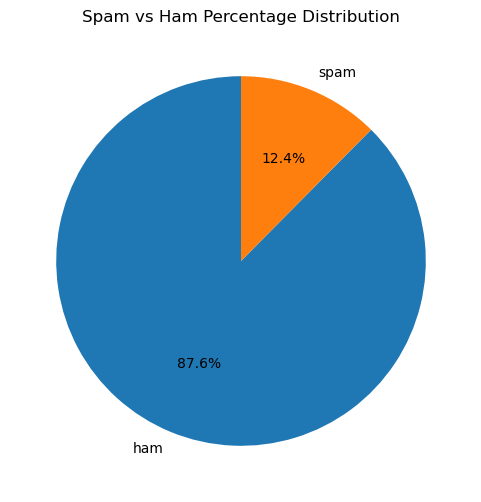

In [24]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Spam vs Ham Percentage Distribution')

plt.show()

#### Message Length Distribution

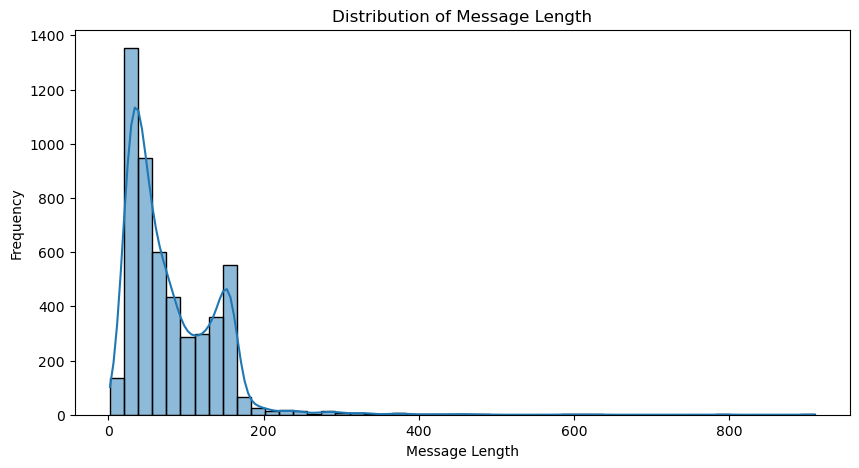

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='character_count',
    bins=50,
    kde=True
)

plt.title('Distribution of Message Length')
plt.xlabel('Message Length')
plt.ylabel('Frequency')

plt.show()

#### Message Length — Spam vs Ham

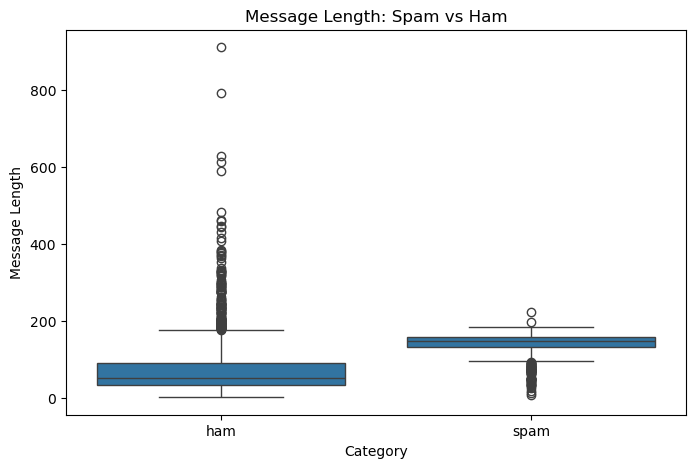

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='category',
    y='character_count'
)

plt.title('Message Length: Spam vs Ham')
plt.xlabel('Category')
plt.ylabel('Message Length')

plt.show()

#### Word Count Distribution

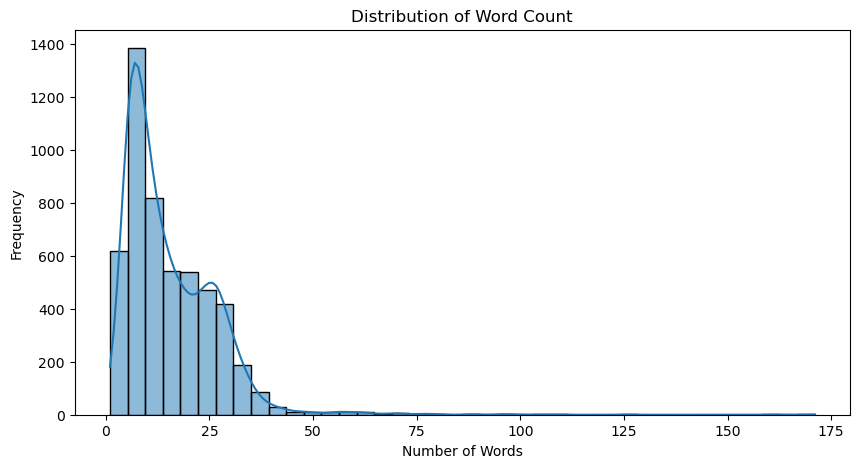

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='word_count',
    bins=40,
    kde=True
)

plt.title('Distribution of Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.show()

#### Word Count — Spam vs Ham

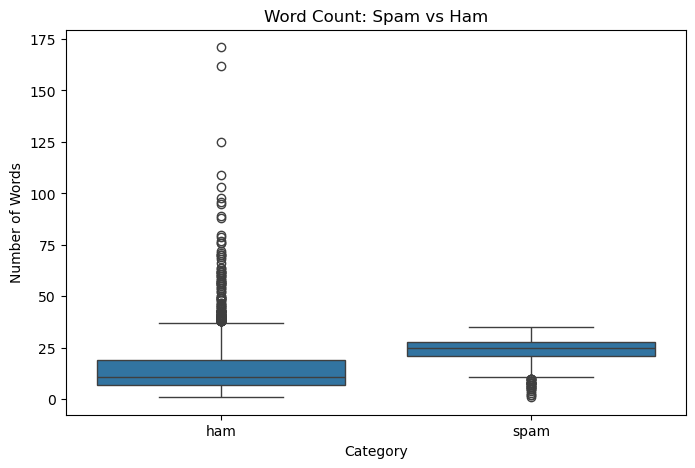

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='category',
    y='word_count'
)

plt.title('Word Count: Spam vs Ham')
plt.xlabel('Category')
plt.ylabel('Number of Words')

plt.show()

In [32]:
from collections import Counter
import re

stop_words = {
    'a', 'an', 'the', 'and', 'or', 'but', 'if', 'then', 'than',
    'to', 'of', 'in', 'on', 'for', 'with', 'at', 'by', 'from',
    'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'i', 'you', 'he', 'she', 'it', 'we', 'they',
    'this', 'that', 'these', 'those',
    'am', 'do', 'does', 'did',
    'have', 'has', 'had',
    'not', 'so', 'as', 'your', 'my', 'me', 'our',
    'their', 'his', 'her', 'its',
    'can', 'will', 'just'
}

In [37]:
def get_common_words(category, n=20):
    text = ' '.join(
        df[df['category'] == category]['message'].astype(str)
    ).lower()

    words = re.findall(r'[a-zA-Z]+', text)

    words = [
        word for word in words
        if word not in stop_words and len(word) > 1
    ]

    return Counter(words).most_common(n)

In [38]:
get_common_words('spam')

[('call', 313),
 ('free', 192),
 ('now', 166),
 ('txt', 139),
 ('ur', 119),
 ('stop', 115),
 ('text', 109),
 ('mobile', 107),
 ('reply', 96),
 ('claim', 94),
 ('www', 81),
 ('prize', 78),
 ('get', 70),
 ('only', 67),
 ('no', 66),
 ('cash', 64),
 ('new', 64),
 ('send', 59),
 ('uk', 59),
 ('urgent', 56)]

In [39]:
get_common_words('ham')

[('get', 301),
 ('how', 299),
 ('up', 288),
 ('gt', 288),
 ('lt', 287),
 ('now', 282),
 ('no', 275),
 ('when', 267),
 ('what', 264),
 ('ok', 256),
 ('go', 248),
 ('ll', 233),
 ('all', 231),
 ('got', 228),
 ('know', 226),
 ('like', 224),
 ('good', 217),
 ('come', 215),
 ('out', 206),
 ('ur', 203)]

#### Top 15 Spam Words

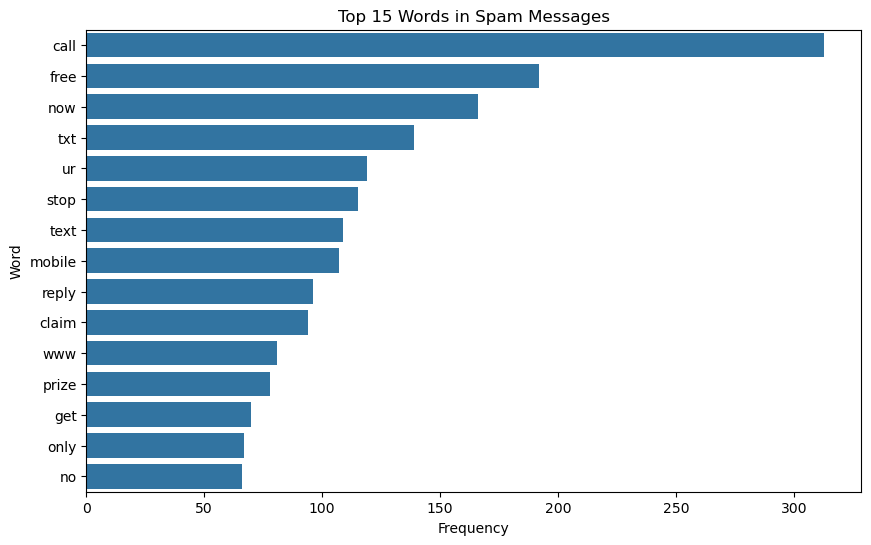

In [41]:
spam_words = get_common_words('spam', 15)

words = [x[0] for x in spam_words]
counts = [x[1] for x in spam_words]

plt.figure(figsize=(10,6))

sns.barplot(x=counts, y=words)

plt.title('Top 15 Words in Spam Messages')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

## SPRINT - 1

#### Encode Taget Variables

In [44]:
df['label'] = df['category'].map({
    'ham': 0,
    'spam': 1
})

In [45]:
df[['category', 'label']].head()

,category,label
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [46]:
df['label'].isnull().sum()

np.int64(0)

#### Select X and y

In [48]:
X = df['message']
y = df['label']

In [49]:
X.head()

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: object

In [50]:
y.head()

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64

#### Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4125
Testing samples: 1032


#### Text Cleaning

In [53]:
import re

In [54]:
def clean_text(text):
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [55]:
sample = X_train.iloc[0]

print("Original:")
print(sample)

print("\nCleaned:")
print(clean_text(sample))

Original:
Saw Guys and Dolls last night with Patrick Swayze it was great

Cleaned:
saw guys and dolls last night with patrick swayze it was great


#### Apply Text Cleaning

In [56]:
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

In [57]:
X_train_clean.head()

4796    saw guys and dolls last night with patrick swa...
764     nothing but we jus tot u would ask cos u ba gu...
3657    oh really did you make it on air whats your ta...
5098    themobhit the link to get a premium pink panth...
4834    new mobiles from must go txt nokia to no colle...
Name: message, dtype: object

#### Stopword Removal

In [58]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gorli\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [59]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [60]:
def remove_stopwords(text):
    words = text.split()
    
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    return ' '.join(words)

In [61]:
remove_stopwords("this is a very good message for you")

'good message'

#### Apply Stopword Removal

In [62]:
X_train_clean = X_train_clean.apply(remove_stopwords)
X_test_clean = X_test_clean.apply(remove_stopwords)

In [63]:
X_train_clean.head()

4796       saw guys dolls last night patrick swayze great
764     nothing jus tot u would ask cos u ba gua went ...
3657                      oh really make air whats talent
5098    themobhit link get premium pink panther game n...
4834    new mobiles must go txt nokia collect today op...
Name: message, dtype: object

#### Stemming

In [64]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [65]:
def stemming(text):
    words = text.split()
    
    words = [
        stemmer.stem(word)
        for word in words
    ]
    
    return ' '.join(words)

In [66]:
stemming("playing played plays")

'play play play'

#### Apply Stemming

In [67]:
X_train_clean = X_train_clean.apply(stemming)
X_test_clean = X_test_clean.apply(stemming)

#### Check Before and After

In [68]:
comparison = pd.DataFrame({
    'Original': X_train.head(10).values,
    'Processed': X_train_clean.head(10).values
})

comparison

,Original,Processed
0,Saw Guys and Dolls last night with Patrick Swa...,saw guy doll last night patrick swayz great
1,Nothing but we jus tot u would ask cos u ba gu...,noth ju tot u would ask co u ba gua went mt fa...
2,Oh really?? Did you make it on air? What's you...,oh realli make air what talent
3,TheMob>Hit the link to get a premium Pink Pant...,themobhit link get premium pink panther game n...
4,"New Mobiles from 2004, MUST GO! Txt: NOKIA to ...",new mobil must go txt nokia collect today opto...
5,Easy ah?sen got selected means its good..,easi ahsen got select mean good
6,Oh did you charge camera,oh charg camera
7,"Get 3 Lions England tone, reply lionm 4 mono o...",get lion england tone repli lionm mono lionp p...
8,My sort code is and acc no is . The bank is n...,sort code acc bank natwest repli confirm ive s...
9,I dont want to hear philosophy. Just say what ...,dont want hear philosophi say happen


#### Convert Text into Numbers — TF-IDF

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [70]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [71]:
X_train_tfidf = tfidf.fit_transform(X_train_clean)

In [72]:
X_test_tfidf = tfidf.transform(X_test_clean)

In [73]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4125, 5000)
Testing shape: (1032, 5000)


#### Inspect TF-IDF Features

In [74]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['aa' 'aah' 'aaooooright' 'aathilov' 'abdomen' 'abeg' 'aberdeen' 'abi'
 'abil' 'abiola' 'abl' 'abnorm' 'abouta' 'abroad' 'absolut' 'abt' 'abta'
 'aburo' 'abus' 'ac' 'acc' 'accent' 'accentur' 'accept' 'access' 'accid'
 'accident' 'accommodationvouch' 'accomod' 'accordingli' 'accordinglyor'
 'account' 'ach' 'achanammarakheshqatar' 'achiev' 'acknowledg' 'aclpm'
 'acnt' 'acoentri' 'across' 'acsmsreward' 'act' 'actin' 'action' 'activ'
 'actor' 'actual' 'acwicmbcktzr' 'ad' 'adam']


In [75]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 31840 stored elements and shape (4125, 5000)>

#### Check Class Distribution After Split

In [76]:
y_train.value_counts()

label
0    3612
1     513
Name: count, dtype: int64

In [77]:
y_test.value_counts()

label
0    904
1    128
Name: count, dtype: int64

In [78]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
label
0    87.563636
1    12.436364
Name: proportion, dtype: float64

Testing distribution:
label
0    87.596899
1    12.403101
Name: proportion, dtype: float64


## SPRINT - 2

#### Import the Models

In [79]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

#### Model 1 — Multinomial Naive Bayes

In [80]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [81]:
y_pred_nb = nb_model.predict(X_test_tfidf)

#### Model 2 — Logistic Regression

In [82]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [83]:
y_pred_lr = lr_model.predict(X_test_tfidf)

#### Model 3 — Linear SVM

In [84]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [85]:
y_pred_svm = svm_model.predict(X_test_tfidf)

#### Evaluation Metrics

In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

#### Evaluate Naive Bayes

In [87]:
print("Naive Bayes")
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

Naive Bayes
Accuracy : 0.9622093023255814
Precision: 1.0
Recall   : 0.6953125
F1 Score : 0.8202764976958525


In [88]:
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       904
        Spam       1.00      0.70      0.82       128

    accuracy                           0.96      1032
   macro avg       0.98      0.85      0.90      1032
weighted avg       0.96      0.96      0.96      1032



#### Evaluate Logistic Regression

In [89]:
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Logistic Regression
Accuracy : 0.9612403100775194
Precision: 0.9680851063829787
Recall   : 0.7109375
F1 Score : 0.8198198198198198


In [90]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       904
        Spam       0.97      0.71      0.82       128

    accuracy                           0.96      1032
   macro avg       0.96      0.85      0.90      1032
weighted avg       0.96      0.96      0.96      1032



#### Evaluate Linear SVM

In [91]:
print("Linear SVM")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Linear SVM
Accuracy : 0.9748062015503876
Precision: 0.9473684210526315
Recall   : 0.84375
F1 Score : 0.8925619834710744


In [92]:
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       904
        Spam       0.95      0.84      0.89       128

    accuracy                           0.97      1032
   macro avg       0.96      0.92      0.94      1032
weighted avg       0.97      0.97      0.97      1032



#### Compare All Models

In [96]:
results = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression',
        'Linear SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm)
    ]
})

# Rank models based on F1 Score
results = results.sort_values(
    by='F1 Score',
    ascending=False
).reset_index(drop=True)

# Add rank
results.insert(0, 'Rank', range(1, len(results) + 1))

results

,Rank,Model,Accuracy,Precision,Recall,F1 Score
0,1,Linear SVM,0.974806,0.947368,0.843750,0.892562
1,2,Naive Bayes,0.962209,1.000000,0.695312,0.820276
2,3,Logistic Regression,0.961240,0.968085,0.710938,0.819820


#### Visualize Model Comparison

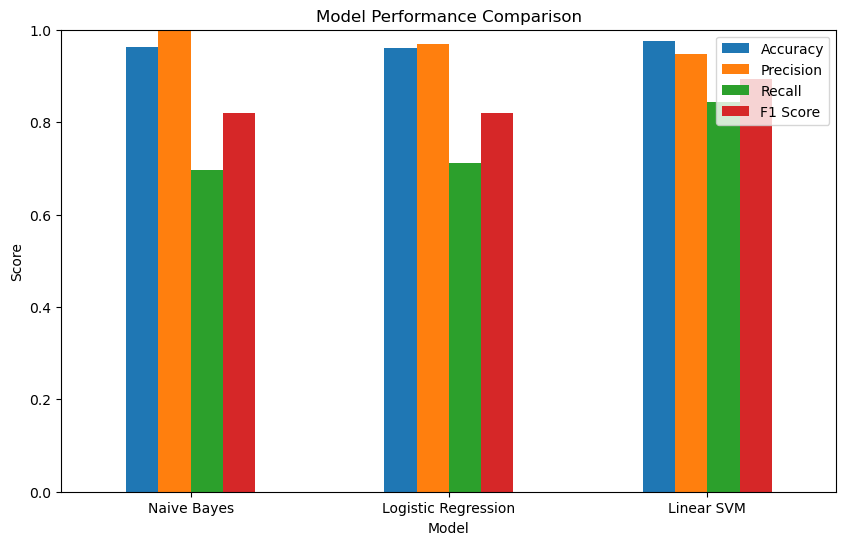

In [94]:
results.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

## SPRINT - 3

In [97]:
final_model = svm_model

y_pred_final = final_model.predict(X_test_tfidf)

In [98]:
print("Final NLP Architecture - Linear SVM")
print("------------------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))

Final NLP Architecture - Linear SVM
------------------------------------
Accuracy : 0.9748062015503876
Precision: 0.9473684210526315
Recall   : 0.84375
F1 Score : 0.8925619834710744


In [99]:
print(classification_report(
    y_test,
    y_pred_final,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       904
        Spam       0.95      0.84      0.89       128

    accuracy                           0.97      1032
   macro avg       0.96      0.92      0.94      1032
weighted avg       0.97      0.97      0.97      1032



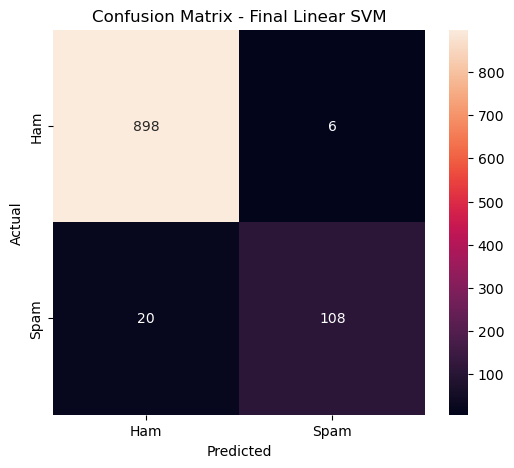

In [100]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix - Final Linear SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Sprint 3 Conclusion

The final NLP architecture was developed using text preprocessing,
TF-IDF feature extraction, and Linear SVM classification. Linear SVM
was selected as the final model based on the Sprint 2 comparison,
achieving an accuracy of 97.48% and an F1-score of 89.26%.

The final architecture was evaluated using accuracy, precision,
recall, F1-score, and a confusion matrix. The system can classify
SMS messages into Ham and Spam categories.

### Save final model

In [101]:
import joblib

joblib.dump(svm_model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [102]:
import os

print(os.path.exists("spam_model.pkl"))
print(os.path.exists("tfidf_vectorizer.pkl"))

True
True
